Используется файл: ../data/mart/variant_03\mart_daily_2026-03-28_22-41-14.csv


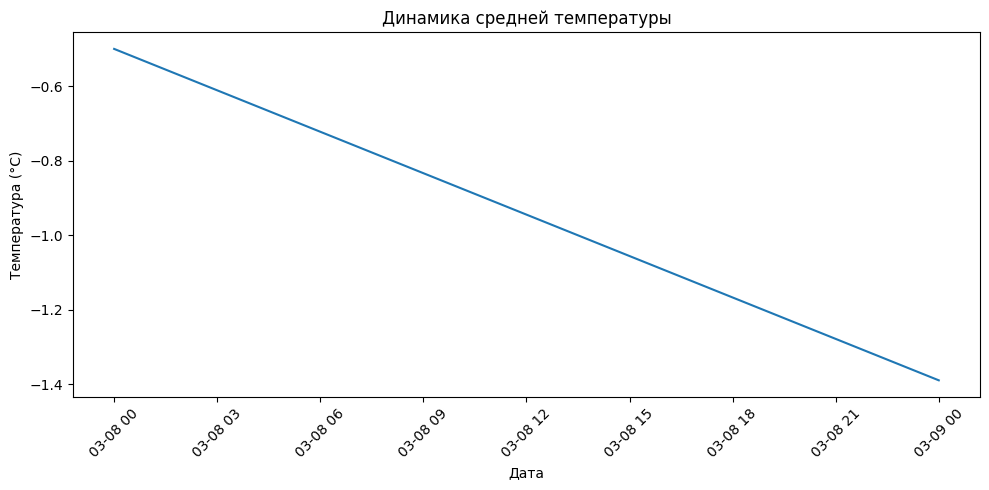

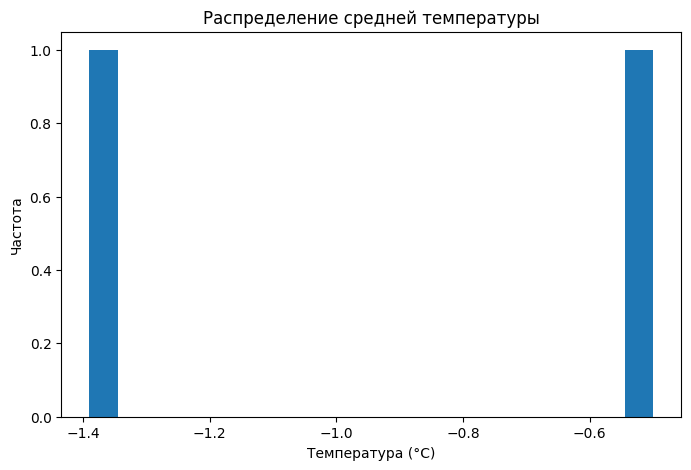

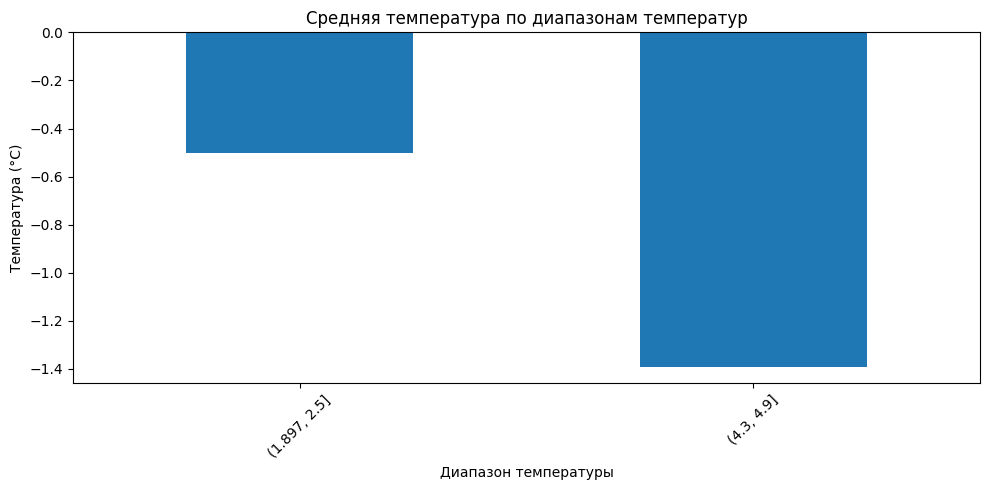

In [10]:

import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

path = "../data/mart/variant_03/*.csv"

files = glob.glob(path)

if not files:
    raise ValueError("Нет CSV файлов в data/mart")

latest_file = max(files, key=os.path.getmtime)

print("Используется файл:", latest_file)

df = pd.read_csv(latest_file)

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

df.head()

plt.figure(figsize=(10, 5))

plt.plot(df["date"], df["temperature_mean"])

plt.title("Динамика средней температуры")
plt.xlabel("Дата")
plt.ylabel("Температура (°C)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("week7_timeseries.png")
plt.show()

plt.figure(figsize=(8, 5))

plt.hist(df["temperature_mean"], bins=20)

plt.title("Распределение средней температуры")
plt.xlabel("Температура (°C)")
plt.ylabel("Частота")

plt.savefig("week7_distribution.png")
plt.show()

df["range_bucket"] = pd.cut(df["temperature_range"], bins=5)

top = (
    df.groupby("range_bucket")["temperature_mean"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
top.plot(kind="bar")

plt.title("Средняя температура по диапазонам температур")
plt.xlabel("Диапазон температуры")
plt.ylabel("Температура (°C)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("week7_ranking.png")
plt.show()

## Выводы

1. **Временной ряд:**  
Температура изменяется во времени, наблюдаются колебания значений по датам.

2. **Распределение:**  
Основная часть значений температуры находится в одном диапазоне, при этом присутствуют отклонения от типичных значений.

3. **Ranking / bar chart:**  
Средняя температура различается между диапазонами temperature_range, что указывает на неоднородность данных.